## Montando DF

In [1]:
import torch
from torchinfo import summary
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from codecarbon import EmissionsTracker
import datetime
import sys
from typing import Union
from scipy.optimize import minimize_scalar

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from core.models.encdec_model import EncDecModel
from core.models.stacked_rnn import Stacked_RNN
from domains.previsao_ceu.dataset_module_group import SolarEfficientDatasetGroups
from domains.previsao_ceu.preprocessing import SolarPreprocessor
from core.utils.experiment_manager import ExperimentManager
from core.utils.early_stopping import EarlyStopping
from auxiliary_models.brl_diffuse import BRL
from auxiliary_models.kasten_correction import Kasten_Correction
from core.loss_function.cpiloss import CPILoss
from core.loss_function.mseloss import MaskedMSELoss
from core.loss_function.pyloss import PhysicsGuidedLoss

In [2]:
CONFIG = {
    # --- 1. PATH DA BASE DE DADOS ---
    'csv_path': 'data/pv0.csv',
    
    # --- 2. DIVISÃO DA BASE DE TREINO, TESTE E VALIDAÇÃO ---
    'split_ratios': {'train': 0.8, 'val': 0.2}, 
    'test_year':2022,

    # --- 3. PRÉ-PROCESSAMENTO (Física & Mapeamento) ---
    'preprocessing': {
        'latitude': -23.56,
        'longitude': -46.73,
        'altitude': 0,
        'timezone': 'Etc/GMT+3',
        'nominal_power': 156.0,
        'start_year': 2015,
        'features_to_scale':['temp_amb','wind_speed'],
        #'pv_power_col_csv': 'Pot_BT', # <--- AVALIAR PARA RETIRAR
        
        # DOCUMENTAÇÃO VIVA: Mapeamento "De -> Para"
        # O Preprocessor usará isso para renomear as colunas internamente.
        # Chave (Esquerda): Nome como está no CSV bruto.
        # Valor (Direita): Nome padronizado usado no código.
        'column_mapping': {
            'Pot_BT': 'target',
            'Irradiação Global horária(horizontal) kWh/m2': 'ghi',
            'Irradiação Difusa horária kWh/m2': 'dhi',
            'Irradiação Global horária(Inclinada 27°) kWh/m2': 'irrad_poa',
            'Temperatura ambiente °C': 'temp_amb',
            'Umidade Relativa %': 'humidity',
            'Velocidade média do vento m/s': 'wind_speed'
        }
    },

    # --- 4. ESTRATÉGIA DE MODELAGEM ---
    # mode: 'sky' (prevê k) ou 'power' (prevê kW normalizado)
    'prediction_mode': 'sky',
    
    # Qual variável o modelo vai prever? ('k' ou 'target')
    'target_col': ['kt', 'fracao_difusa'], 
    
    # Features de entrada
    'feature_cols': [
        "kt",'fracao_difusa',
        'cos_zenith', 'elevation', 'delta_kt', 
        'delta_fracao_difusa', 'QS', 
        'temp_amb', 'humidity', 'wind_speed'
    ],
    
    'aux_col':[
        'ghi_cs', 'cos_zenith', 
        'elevation', 'ghi_extra'
    ],

    # --- 5. ARQUITETURA E TREINO ---
    'model_type': 'Teste',
    'cell_type': 'lstm',
    'input_seq_len': 24,
    'output_seq_len': 1,
    'hidden_sizes': [300],
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 10000,
    'dropout': 0.1,
    'bidirectional': False,
    'use_attention': False,
    'use_feature_attention': False,
    'patience': 100,
    'use_mask':True,
    'loss_function':'physics_loss',      # "cpi_loss", "mse", physics_loss
    'physics_base_loss': 'cpi',
    'lambda_hard':1,
    'lambda_soft':1,
}

OUTPUT_ROOT = 'trained_models'
ARTIFACTS_DIR = 'artifacts'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# 1. Setup
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
exp_name = f"{timestamp}_{CONFIG['model_type']}"
exp_dir = os.path.join(OUTPUT_ROOT, exp_name)
os.makedirs(exp_dir, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# 2. Leitura
#csv_path = CONFIG['data/pv0.csv']
#print(f"⏳ Lendo: {csv_path}")
df = pd.read_csv('/workspaces/Remodelacao_mestrado/data/pv0.csv')


if 'Date_Time' in df.columns:
    df['Date_Time'] = pd.to_datetime(df['Date_Time'])
    #df['Date_Time'] -=  pd.Timedelta(minutes=30)
    df = df.drop_duplicates(subset=['Date_Time'], keep='first').set_index('Date_Time').sort_index()
df = df[~df.index.duplicated(keep='first')]

# 3. Pré-processamento
pp_conf = CONFIG['preprocessing']

# Instancia passando o mapa explícito. 
# Isso garante que a padronização aconteça conforme o CONFIG acima.
preprocessor = SolarPreprocessor(
    latitude=pp_conf['latitude'], 
    longitude=pp_conf['longitude'], 
    altitude=pp_conf['altitude'],
    timezone=pp_conf['timezone'], 
    nominal_power=pp_conf['nominal_power'], 
    start_year=pp_conf['start_year'],
    cs_model = 'esra',
    features_to_scale=pp_conf['features_to_scale'],
    target_col=CONFIG['prediction_mode'], # <--- unica variavel que não vem do preprocessing
    column_mapping=pp_conf['column_mapping'],
    kasten_corr=True
)

preprocessor.fit(df)
preprocessor.save_scalers(exp_dir)
preprocessor.save_scalers(ARTIFACTS_DIR)

# O método transform usa o column_mapping para renomear as colunas
df_processed = preprocessor.transform(df)

💾 Scalers salvos em: trained_models/2026-03-19_17-09-10_Teste
💾 Scalers salvos em: artifacts
Otimizando TL para 381 dias selecionados...
Otimização concluída. Média TL: 6.28


## Prevendo com base na previsão anterior

In [4]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from evaluation.analysis_k_factor import KFactorAnalyzer
from domains.previsao_ceu.dataset import SolarEfficientDataset
import json

In [5]:
EXPERIMENTS_DIRS = [
    "trained_models/2026-01-28_17-05-32_Teste_kt_kd"
]

OUTPUT_FILE = "analysis_outputs/Fisica_Atmosferica/"

In [6]:
def get_config(exp_dir):
    path = os.path.join(exp_dir, 'config.json')
    if not os.path.exists(path):
        raise FileNotFoundError(f"Config não achado em {exp_dir}")
    with open(path, 'r') as f:
        return json.load(f)

def get_preprocessing_params(config):
    pp = config.get('preprocessing', {})
    return {
        'latitude': pp.get('latitude', config.get('latitude', -15.60)),
        'longitude': pp.get('longitude', config.get('longitude', -47.70)),
        'altitude': pp.get('altitude', config.get('altitude', 0)),
        'timezone': pp.get('timezone', config.get('timezone', 'Etc/GMT+3')),
        'nominal_power': pp.get('nominal_power', config.get('nominal_power', 156.0)),
        'target_col': config.get('target_col', 'target'),
        'column_mapping': pp.get('column_mapping', config.get('column_map', None)),
        'start_year': pp.get('start_year', config.get('start_year', 2018)),
        'features_to_scale': pp.get('features_to_scale', config.get('features_to_scale', []))
    }

def process_model_single_day(exp_dir, loader, recursive_steps=10, target_indices=[0, 1]):
    """
    Simula o efeito cascata autoregressivo para UM ÚNICO DIA, coletando os dados reais.
    Aplica persistência meteorológica (t-24) para as variáveis exógenas.
    
    Args:
        exp_dir: Diretório do experimento com os pesos.
        loader: DataLoader filtrado para o dia alvo (ex: contendo as horas das 08h às 17h).
        recursive_steps: Quantas horas do dia simular (ex: 10 horas).
        target_indices: Posições das colunas (kt e kd) no tensor batch_x.
    """
    print(f"\n📂 Iniciando Simulação de Dia Único: {os.path.basename(exp_dir)}")
    
    # 1. Configurações
    config = get_config(exp_dir)
    n_future = config['output_seq_len']
    
    # Validação de segurança para a persistência t-24
    if config['input_seq_len'] < 24:
        raise ValueError("O modelo precisa de um input_seq_len (n_past) >= 24 para usar a persistência de t-24.")
    
    # 2. Inicialização do Modelo
    model = EncDecModel(
        input_size=len(config['feature_cols']),
        hidden_sizes=config['hidden_sizes'],
        output_seq_len=n_future,
        output_dim=len(config['target_col']), 
        cell_type=config.get('cell_type', 'gru'),
        bidirectional=config.get('bidirectional', False),
        use_attention=config.get('use_attention', False),
        use_feature_attention=config.get('use_feature_attention', False)
    ).to(DEVICE)
    
    # 3. Carrega os pesos
    w_path = os.path.join(exp_dir, 'best_model.pt')
    if not os.path.exists(w_path): w_path = os.path.join(exp_dir, 'best_model.pth')
    model.load_state_dict(torch.load(w_path, map_location=DEVICE), strict=False)
    model.eval()

    print(f"   🔮 Gerando cascata autoregressiva e coletando reais ({recursive_steps}h)...")
    
    preds_cascata = []
    reais_cascata = []
    
    # Transforma o loader em um iterador manual para avançarmos hora a hora
    loader_iter = iter(loader)
    
    with torch.no_grad():
        # --- PASSO 0: Inicialização (A primeira hora do dia, ex: 08h00) ---
        try:
            batch_x, batch_y, _, _ = next(loader_iter)
        except StopIteration:
            raise ValueError("O DataLoader está vazio.")
            
        # Pega apenas a primeira amostra do lote inicial para ser a nossa raiz
        x_deslizante = batch_x[0:1].to(DEVICE) 
        
        # O batch_y atual é o gabarito real da nossa primeira previsão
        reais_cascata.append(batch_y[0:1].cpu().numpy())
        
        # Faz a previsão da 1ª hora (ex: 08h)
        out = model(x_deslizante)
        preds_cascata.append(out.cpu().numpy())

        # --- LOOP AUTOREGRESSIVO: Próximas horas (ex: 09h em diante) ---
        for t in range(1, recursive_steps):
            
            # Puxamos o gabarito REAL da próxima hora iterando o DataLoader
            try:
                next_batch_x, next_batch_y, _, _ = next(loader_iter)
                # Salvamos o gabarito real (ignora o next_batch_x, não vamos usar!)
                reais_cascata.append(next_batch_y[0:1].cpu().numpy())
            except StopIteration:
                print(f"   ⚠️ Aviso: O DataLoader acabou no passo {t}. O dataset filtrado tem menos horas que 'recursive_steps'.")
                break 

            # 1. Desliza a janela do nosso x_deslizante customizado
            janela_cortada = x_deslizante[:, 1:, :]
            
            # 2. PERSISTÊNCIA t-24: 
            # A nova hora copia TODAS as variáveis meteorológicas exatamente da mesma hora no dia anterior.
            nova_hora = x_deslizante[:, -24:-23, :].clone()
            
            # 3. INJEÇÃO DA PREVISÃO:
            # Substituímos APENAS o kt e kd reais pela previsão (com erro) que a LSTM acabou de fazer
            nova_hora[:, 0, target_indices] = out.squeeze(1)

            #elevação e cos zenith são mantidos pq são calculaveis
            nova_hora[:, 0, [0,1]] = next_batch_x[:,-1,[0,1]].to(DEVICE)
            # calculo do novo delta para kt e kd
            nova_hora[:, 0, [2,3]] = out.squeeze(1) - x_deslizante[:, -1, target_indices]

            # 4. Atualiza a janela
            x_deslizante = torch.cat((janela_cortada, nova_hora), dim=1)
            
            # 5. Faz a nova previsão (ex: 09h)
            out = model(x_deslizante)
            preds_cascata.append(out.cpu().numpy())

    # ---------------------------------------------------------
    # ESTRUTURAÇÃO DO DATAFRAME FINAL PARA PLOTAGEM
    # ---------------------------------------------------------
    # Concatena as listas (Shape esperado: [passos_reais_simulados, output_dim])
    y_pred_dia = np.concatenate(preds_cascata, axis=0).squeeze(1)
    y_real_dia = np.concatenate(reais_cascata, axis=0).squeeze(1)
    
    passos_simulados = len(y_pred_dia)

    df_analysis = pd.DataFrame({
        'hora_simulacao': range(1, passos_simulados + 1),
        'kt_real': y_real_dia[:, 0],
        'kd_real': y_real_dia[:, 1],
        'kt_pred': y_pred_dia[:, 0],
        'kd_pred': y_pred_dia[:, 1]
    })
    
    # (Opcional) Podemos indexar pela hora_simulacao para facilitar o plot direto
    df_analysis.set_index('hora_simulacao', inplace=True)

    print(f"   ✅ Simulação concluída! DataFrame gerado com {passos_simulados} horas.")

    return df_analysis, os.path.basename(exp_dir), model

In [7]:
df_teste = df_processed[df_processed.index.year == 2022]
dia = datetime.date(2022, 1, 2)
df_resultado = None

while dia < datetime.date(2022, 12, 31):
    analise_dia = df_teste.loc[
        (df_teste.index.date >= dia - datetime.timedelta(days=1)) & 
        (df_teste.index.date <= dia)]
    
    config_modelo = get_config(EXPERIMENTS_DIRS[0])
    test_dataset = SolarEfficientDataset(
        analise_dia,     
        feature_cols=config_modelo['feature_cols'], # <-- O segredo está aqui (as 8 colunas)
        target_col=config_modelo['target_col'],
        aux_col=config_modelo['aux_col'], # Ou a chave correta no seu config
        n_past=config_modelo['input_seq_len'],
        n_future=config_modelo['output_seq_len'])
    
    if len(test_dataset) == 0:
        print(f"⚠️ Dia {dia} ignorado: Dados insuficientes ou barrados no controle de qualidade.")
        dia += datetime.timedelta(days=1)
        continue # Pula para a próxima iteração do 'while'

    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    # Roda a função para um DataLoader que contenha o dia específico
    df_simulacao, nome_exp, _ = process_model_single_day(
        EXPERIMENTS_DIRS[0], test_loader, 
        recursive_steps=10,
        target_indices=[6, 7])

    if df_resultado is None:
        df_resultado = pd.merge(
            df_simulacao,
            analise_dia[['kt', 'fracao_difusa']].astype('float32').reset_index(), 
            left_on=['kt_real', 'kd_real'], 
            right_on=['kt', 'fracao_difusa'], 
            how='inner').set_index('Date_Time')
        
    else: 
        df_resultado = pd.concat([
            df_resultado, 
            pd.merge(
                df_simulacao,
                analise_dia[['kt', 'fracao_difusa']].astype('float32').reset_index(), 
                left_on=['kt_real', 'kd_real'], 
                right_on=['kt', 'fracao_difusa'], 
                how='inner').set_index('Date_Time')])

    dia += datetime.timedelta(days=1)

✅ Dataset pronto. Amostras válidas: 10

📂 Iniciando Simulação de Dia Único: 2026-01-28_17-05-32_Teste_kt_kd
   🔮 Gerando cascata autoregressiva e coletando reais (10h)...
   ✅ Simulação concluída! DataFrame gerado com 10 horas.
✅ Dataset pronto. Amostras válidas: 10

📂 Iniciando Simulação de Dia Único: 2026-01-28_17-05-32_Teste_kt_kd
   🔮 Gerando cascata autoregressiva e coletando reais (10h)...
   ✅ Simulação concluída! DataFrame gerado com 10 horas.
✅ Dataset pronto. Amostras válidas: 10

📂 Iniciando Simulação de Dia Único: 2026-01-28_17-05-32_Teste_kt_kd
   🔮 Gerando cascata autoregressiva e coletando reais (10h)...
   ✅ Simulação concluída! DataFrame gerado com 10 horas.
✅ Dataset pronto. Amostras válidas: 12

📂 Iniciando Simulação de Dia Único: 2026-01-28_17-05-32_Teste_kt_kd
   🔮 Gerando cascata autoregressiva e coletando reais (10h)...
   ✅ Simulação concluída! DataFrame gerado com 10 horas.
✅ Dataset pronto. Amostras válidas: 10

📂 Iniciando Simulação de Dia Único: 2026-01-28_1

In [8]:
persistencia = df_teste[['kt', 'fracao_difusa']].shift(24).rename(columns={'kt':'P_kt', 'fracao_difusa':'P_fracao_difusa'})
df_resultado = pd.merge(df_resultado[['kt_real', 'kd_real', 'kt_pred', 'kd_pred']],
                        persistencia,
                        left_index=True, right_index=True, how='left')

AttributeError: 'Index' object has no attribute 'hour'

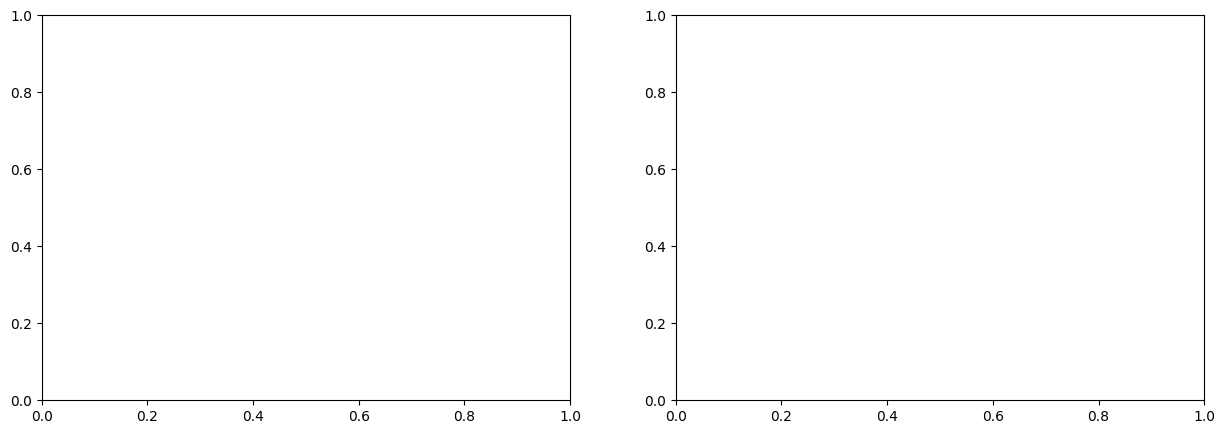

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

persistencia_kt = analise_dia['kt'].loc[analise_dia.index.hour.isin(range(8, 18)) & (analise_dia.index.date == dia - datetime.timedelta(days=1))]
persistencia_kd = analise_dia['fracao_difusa'].loc[analise_dia.index.hour.isin(range(8, 18)) & (analise_dia.index.date == dia - datetime.timedelta(days=1))]

# Gráfico para o Kt
ax[0].plot(df_simulacao.index.hour, df_simulacao['kt_real'], label='Kt Real', marker='o', color='green', drawstyle='steps-post')
ax[0].plot(df_simulacao.index.hour, df_simulacao['kt_pred'], label='Kt Previsto (Cascata + t-24)', marker='x', linestyle='--', color='red', drawstyle='steps-post')
ax[0].plot(persistencia_kt.index.hour, persistencia_kt, label='Kt  (anterior)', marker='x', linestyle='--', color='blue', drawstyle='steps-post')

ax[0].set_title('Degradação da Previsão - Kt')
ax[0].set_xlabel('Horas Simuladas')
ax[0].set_ylabel('Clearance Index (Kt)')
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

# Gráfico para Fração Difusa (Kd)
ax[1].plot(df_simulacao.index.hour, df_simulacao['kd_real'], label='Kd Real', marker='o', color='blue', drawstyle='steps-post')
ax[1].plot(df_simulacao.index.hour, df_simulacao['kd_pred'], label='Kd Previsto (Cascata + t-24)', marker='x', linestyle='--', color='orange', drawstyle='steps-post')
ax[1].plot(persistencia_kd.index.hour, persistencia_kd, label='Kd  (anterior)', marker='x', linestyle='--', color='green', drawstyle='steps-post')
ax[1].set_title('Degradação da Previsão - Fração Difusa')
ax[1].set_xlabel('Horas Simuladas')
ax[1].set_ylabel('Diffuse Fraction (Kd)')
ax[1].legend()
ax[1].grid(True)
ax[1].set_ylim(0, 1)

plt.suptitle(f"Análise de Erro Autoregressivo - Experimento: {nome_exp}")
plt.tight_layout()
plt.show()

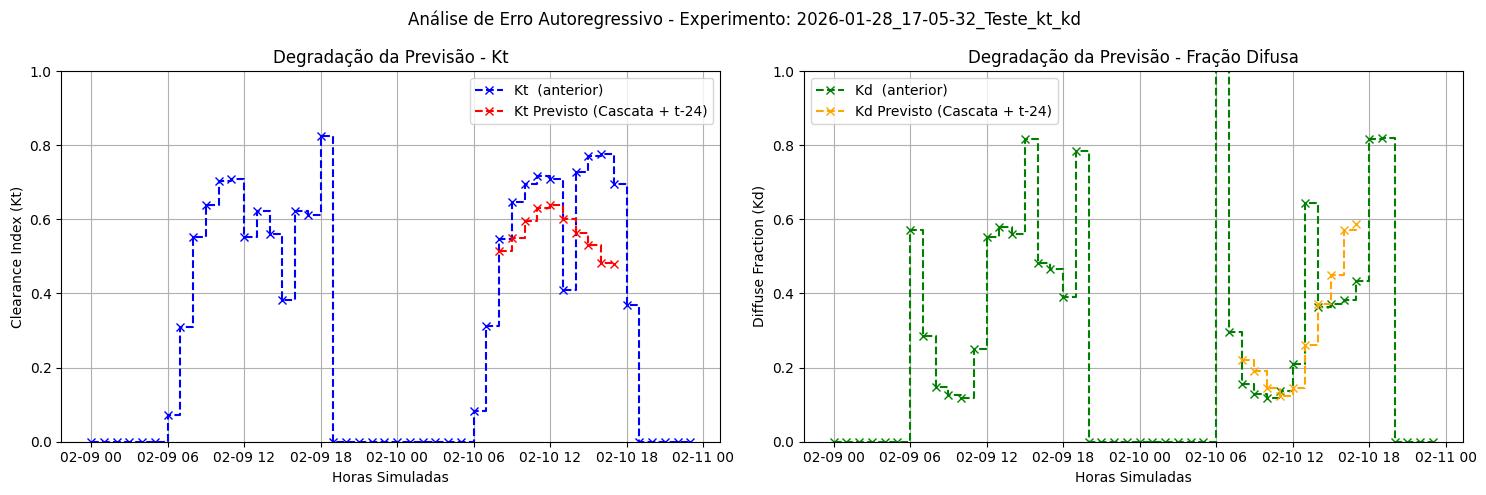

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

persistencia_kt = analise_dia['kt'].loc[analise_dia.index.hour.isin(range(8, 18)) & (analise_dia.index.date == dia - datetime.timedelta(days=1))]
persistencia_kd = analise_dia['fracao_difusa'].loc[analise_dia.index.hour.isin(range(8, 18)) & (analise_dia.index.date == dia - datetime.timedelta(days=1))]

# Gráfico para o Kt
#ax[0].plot(df_simulacao.index.hour, df_simulacao['kt_real'], label='Kt Real', marker='o', color='green', drawstyle='steps-post')
ax[0].plot(analise_dia.index, analise_dia['kt'], label='Kt  (anterior)', marker='x', linestyle='--', color='blue', drawstyle='steps-post')
ax[0].plot(df_simulacao.index, df_simulacao['kt_pred'], label='Kt Previsto (Cascata + t-24)', marker='x', linestyle='--', color='red', drawstyle='steps-post')

ax[0].set_title('Degradação da Previsão - Kt')
ax[0].set_xlabel('Horas Simuladas')
ax[0].set_ylabel('Clearance Index (Kt)')
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

# Gráfico para Fração Difusa (Kd)
ax[1].plot(analise_dia['fracao_difusa'].index, analise_dia['fracao_difusa'], label='Kd  (anterior)', marker='x', linestyle='--', color='green', drawstyle='steps-post')
ax[1].plot(df_simulacao.index, df_simulacao['kd_pred'], label='Kd Previsto (Cascata + t-24)', marker='x', linestyle='--', color='orange', drawstyle='steps-post')
#ax[1].plot(df_simulacao.index.hour, df_simulacao['kd_real'], label='Kd Real', marker='o', color='blue', drawstyle='steps-post')
ax[1].set_title('Degradação da Previsão - Fração Difusa')
ax[1].set_xlabel('Horas Simuladas')
ax[1].set_ylabel('Diffuse Fraction (Kd)')
ax[1].legend()
ax[1].grid(True)
ax[1].set_ylim(0, 1)

plt.suptitle(f"Análise de Erro Autoregressivo - Experimento: {nome_exp}")
plt.tight_layout()
plt.show()

## Correção das previsões

In [11]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from core.utils.quantile_mapping import SolarQuantileMapping

qm_kt = SolarQuantileMapping()
qm_kd = SolarQuantileMapping()
qm_kt.fit(obs_train=df_processed['kt'].loc[(df_processed.index.year != 2022) & (df_processed['mask'] == 1)])
qm_kd.fit(obs_train=df_processed['fracao_difusa'].loc[(df_processed.index.year != 2022) & (df_processed['mask'] == 1)])

df_resultado['kt_pred_corrigido'] = qm_kt.transform(df_resultado['kt_pred'])
df_resultado['kd_pred_corrigido'] = qm_kd.transform(df_resultado['kd_pred'])

## Analise de Resultados

In [12]:
#==================================
#   --- Analise das Previsões ---
#==================================

# 2. INSTÂNCIA DO NOVO ANALYZER
# Passamos o nome do modelo para criar a pasta organizada
k_analyzer = KFactorAnalyzer(model_name="pred_futuro", output_dir="analysis_outputs")

# 3. CHAMADA DA FIGURA DE 3 PLOTS
# Esta função vai gerar o arquivo .png com os dados de teste
#k_analyzer.plot_kt_kd_relationship(df_resultado)
k_analyzer.plot_clear_sky_day_analysis(df_resultado)
k_analyzer.plot_high_variability_day_analysis(df_resultado)
#k_analyzer.plot_overcast_day_analysis(df_resultado)
#k_analyzer.calculate_statistical_metrics(df_resultado)
k_analyzer.plot_scatter_validation(df_resultado)
k_analyzer.plot_transient_day_analysis(df_resultado)

"""
#=================================
#   --- Explainable AI (XAI) ---
#=================================
xai_engine = SolarXAIEngine(model, DEVICE)
xai_dir = os.path.join("analysis_outputs", "XAI", model_name)
os.makedirs(xai_dir, exist_ok=True)

config = get_config(exp_dir)
feature_names = config['feature_cols']

# --- NÍVEL 1: Importância Global (Feature Ablation) ---
xai_engine.compute_global_feature_importance(
    loader=loader,
    feature_names=feature_names,
    save_path=os.path.join(xai_dir, "global_feature_importance.png")
)

# --- NÍVEL 2: Importância Temporal (Integrated Gradients) ---
xai_engine.compute_temporal_importance(
    dataloader=loader, 
    feature_names=feature_names,
    save_path=os.path.join(xai_dir, "temporal_importance_heatmap.png")
)
"""


   ☀️ Dia selecionado (10 amostras): 2022-11-17
   ⛈️ Dia selecionado para alta variabilidade: 2022-10-19
   📈 Gerando matriz de scatter de validação estatística...
   🌦️ Dia Transiente selecionado: 2022-01-03


'\n#=================================\n#   --- Explainable AI (XAI) ---\n#=================================\nxai_engine = SolarXAIEngine(model, DEVICE)\nxai_dir = os.path.join("analysis_outputs", "XAI", model_name)\nos.makedirs(xai_dir, exist_ok=True)\n\nconfig = get_config(exp_dir)\nfeature_names = config[\'feature_cols\']\n\n# --- NÍVEL 1: Importância Global (Feature Ablation) ---\nxai_engine.compute_global_feature_importance(\n    loader=loader,\n    feature_names=feature_names,\n    save_path=os.path.join(xai_dir, "global_feature_importance.png")\n)\n\n# --- NÍVEL 2: Importância Temporal (Integrated Gradients) ---\nxai_engine.compute_temporal_importance(\n    dataloader=loader, \n    feature_names=feature_names,\n    save_path=os.path.join(xai_dir, "temporal_importance_heatmap.png")\n)\n'